# Single Pair Strategy Prototype

This notebook develops the pairs-trading strategy for one asset pair. I start with a simple static hedge ratio and full-sample z-score to understand the mechanics, then replace these with rolling estimates to reduce look-ahead bias.

In [164]:
# imports
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import download_prices
from src.returns import compute_simple_returns
from src.pairs import rank_pairs_by_correlation
from src.spread import estimate_hedge_ratio, compute_spread, compute_zscore, compute_rolling_zscore, compute_rolling_spread
from src.signals import generate_spread_positions
from src.backtest import compute_strategy_returns, compute_strategy_returns_dynamic_beta
from src.metrics import compute_cumulative_returns, compute_performance_metrics
from src.trades import build_trade_log
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
# ticker universe
tickers = [
    "SPY", "QQQ", "IWM",
    "XLK", "XLF", "XLE", "XLV",
    "XLY", "XLP", "XLI", "XLU",
    "TLT", "HYG", "LQD", "GLD",
]

# downloads data
prices = download_prices(
    tickers=tickers,
    start="2015-01-01",
    end="2026-01-01",
)

# computes returns
returns = compute_simple_returns(prices)

# computes correlations between tickers
ranked_pairs = rank_pairs_by_correlation(returns)

# inspect
print(prices.shape)
print(returns.shape)
print(ranked_pairs.shape)
print(ranked_pairs.head(10))

Loading SPY from cache...
Loading QQQ from cache...
Loading IWM from cache...
Loading XLK from cache...
Loading XLF from cache...
Loading XLE from cache...
Loading XLV from cache...
Loading XLY from cache...
Loading XLP from cache...
Loading XLI from cache...
Loading XLU from cache...
Loading TLT from cache...
Loading HYG from cache...
Loading LQD from cache...
Loading GLD from cache...
(2766, 15)
(2765, 15)
(105, 3)
   ticker_1 ticker_2  correlation
15      QQQ      XLK     0.974542
0       SPY      QQQ     0.933781
2       SPY      XLK     0.929819
6       SPY      XLY     0.899924
8       SPY      XLI     0.890521
19      QQQ      XLY     0.885982
54      XLF      XLI     0.873843
1       SPY      IWM     0.867231
33      IWM      XLI     0.857436
3       SPY      XLF     0.846784


Let's get the pairs of tickers which we consider to be highly correlated using a threshold of 0.85

In [5]:
# highly correlated pairs of tickers
high_corr_pairs = ranked_pairs[ranked_pairs["correlation"] >= 0.85]

print(high_corr_pairs)
print(high_corr_pairs.shape)

   ticker_1 ticker_2  correlation
15      QQQ      XLK     0.974542
0       SPY      QQQ     0.933781
2       SPY      XLK     0.929819
6       SPY      XLY     0.899924
8       SPY      XLI     0.890521
19      QQQ      XLY     0.885982
54      XLF      XLI     0.873843
1       SPY      IWM     0.867231
33      IWM      XLI     0.857436
(9, 3)


We will use the top pair to build our pipeline.

## Estimate Hedge Ratio

ticker_y $\rightarrow Y_t = \mathrm{XLK}$, ticker_x $\rightarrow X_t = \mathrm{QQQ}$

We first estimate the hedge ratio using linear regression: $$Y_t = \alpha + \beta X_t + \epsilon_t$$ 

$Y_t$: price data of the target asset we want to hedge (dependent variable).  

$X_t$: price data of the hedging asset we are using to protect our asset (independent variable).  

$\alpha$: intercept coefficient, expected performance difference between assets, expected return of $Y_t$ if $X_t$ has zero movement. 

$\beta$: optimal hedge ratio, tells us exactly how many shares of asset $X$ we need to trade for every share of $Y$.

In [7]:
ticker_y = "XLK"
ticker_x = "QQQ"

In [8]:
# estimate hedge ratio
alpha, beta = estimate_hedge_ratio(
    prices=prices,
    ticker_y=ticker_y,
    ticker_x=ticker_x,
)

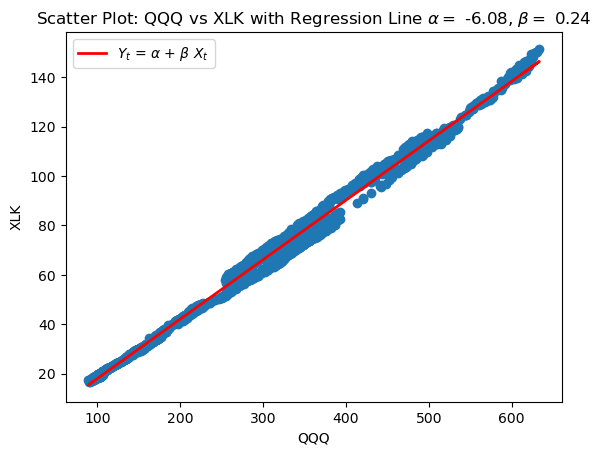

In [9]:
# plot the linear regression
plt.scatter(prices[ticker_x], prices[ticker_y])
plt.plot(prices[ticker_x], alpha + beta*prices[ticker_x], color="red", linewidth=2, label=rf"$Y_t$ = $\alpha$ + $\beta$ $X_t$")
plt.xlabel(ticker_x)
plt.ylabel(ticker_y)
plt.title(rf"Scatter Plot: {ticker_x} vs {ticker_y} with Regression Line $\alpha =$ {round(alpha,2)}, $\beta =$ {round(beta,2)}")
plt.legend()
plt.show()

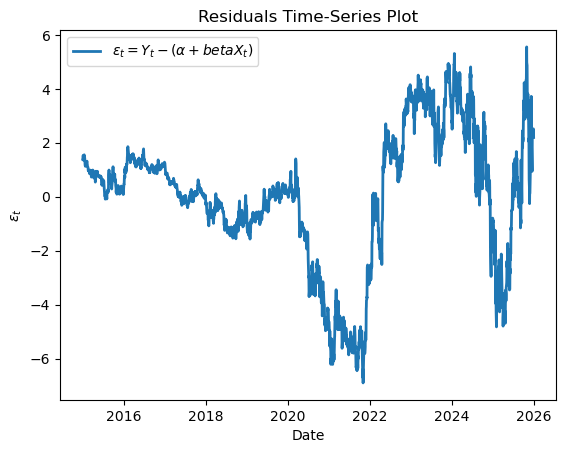

In [10]:
# plot the residual error over time
plt.plot(prices.index, prices[ticker_y] - (alpha + beta*prices[ticker_x]), linewidth=2, label=rf"$\epsilon_t = Y_t - (\alpha + beta X_t)$")
plt.xlabel("Date")
plt.ylabel(r"$\epsilon_t$")
plt.title(rf"Residuals Time-Series Plot")
plt.legend()
plt.show()

## Spread Construction

We generate the spread $S_t$ using the error residual from the linear regression.

$$ S_t = Y_t - (\alpha + \beta X_t)$$

$S_t > 0 \implies Y_t$ is high relative to its estimated relationship to $X_t$

$S_t < 0 \implies Y_t$ is low relative to $X_t$

We are basing our strategy around the spread $S_t$ assuming that there is mean-reversion.

In [12]:
# compute spread
spread = compute_spread(
    prices=prices,
    ticker_y=ticker_y,
    ticker_x=ticker_x,
    alpha=alpha,
    beta=beta,
)

# inspect
print("alpha:", alpha)
print("beta:", beta)
print(spread.head())
print(spread.describe())

alpha: -6.083477534786367
beta: 0.24068529955583914
Date
2015-01-02    1.386741
2015-01-05    1.444847
2015-01-06    1.531087
2015-01-07    1.394679
2015-01-08    1.355285
Name: XLK_QQQ_spread, dtype: float64
count    2.766000e+03
mean    -4.282780e-14
std      2.489940e+00
min     -6.904320e+00
25%     -1.007093e+00
50%      2.242802e-01
75%      1.381208e+00
max      5.553757e+00
Name: XLK_QQQ_spread, dtype: float64


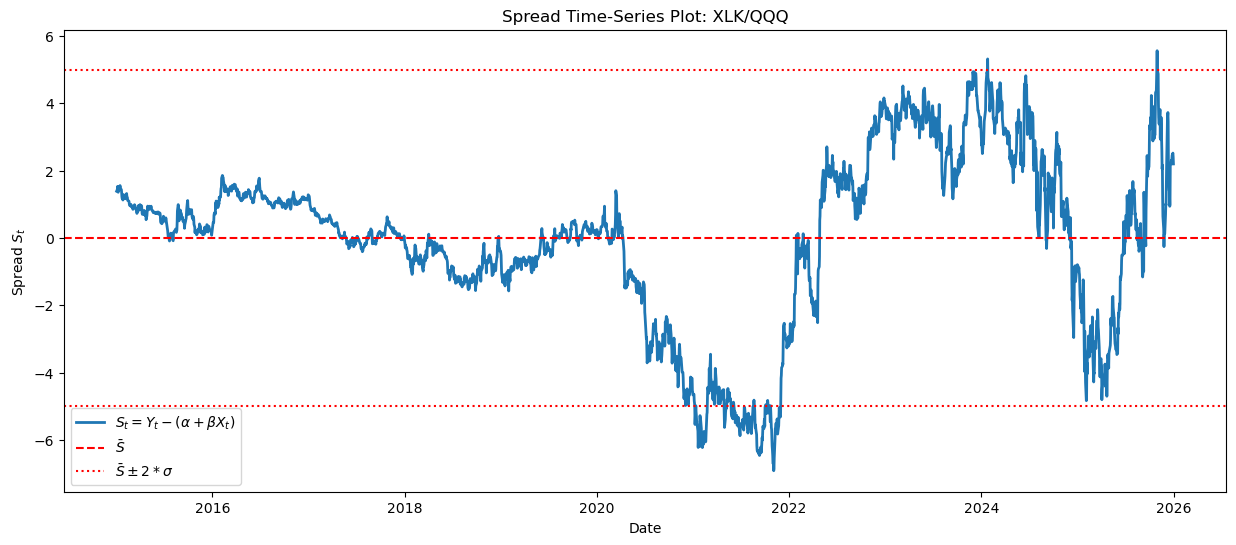

In [56]:
# add in standard deviations
plt.figure(figsize=(15, 6))
plt.plot(prices.index, spread, linewidth=2, label=rf"$S_t = Y_t - (\alpha + \beta X_t)$")
plt.axhline(spread.mean(), color="red", linestyle="--", label=r"$\bar{S}$")
plt.axhline(spread.mean() + 2 * spread.std(), color="red", linestyle=":", label=r"$\bar{S} \pm 2*\sigma$")
plt.axhline(spread.mean() - 2 * spread.std(), color="red", linestyle=":")
plt.title(rf"Spread Time-Series Plot: {ticker_y}/{ticker_x}")
plt.xlabel("Date")
plt.ylabel(r"Spread $S_t$")
plt.legend()
plt.show()

## Trading Rule Construction

We standardize the spread using z-score $$z_t = \frac{S_t - \bar{S}}{\sigma}$$

where $\bar{S}$ is the mean of the spread and $\sigma$ is the standard deviation. It is the number of standard deviations by which the value of the spread is above or below the mean. When the z-score is above the entry threshold, the spread is unusually high, so the strategy shorts the spread. When the z-score is below the negative entry threshold, the spread is unusually low, so the strategy longs the spread. Positions are exited when the z-score returns close to zero.

We will use the simple rule that we enter a position when zscore $|z_t| \geq 2$ and exit a position when $|z_t| \leq 0.5$. 

When $z_t \geq 2 \implies Y_t$ is expensive compared to $X_t \implies$ short 1 unit of $Y$, long $\beta$ units of $X$.

When $z_t \leq -2 \implies Y_t$ is cheap compared to $X_t \implies$ long 1 unit of $Y$, short $\beta$ units of $X$.

When $-0.5 \leq z_t \leq 0.5$, then the spread has moved closer to normal and we exit the position/trade.

In [15]:
# compute zscore
zscore = compute_zscore(spread)

In [16]:
# entry/exit position thresholds
entry_threshold = 2
exit_threshold = 0.5

In [17]:
# inspect
zscore.head()
zscore.describe()

count    2.766000e+03
mean    -5.137692e-17
std      1.000000e+00
min     -2.772886e+00
25%     -4.044649e-01
50%      9.007456e-02
75%      5.547155e-01
max      2.230479e+00
Name: XLK_QQQ_spread_zscore, dtype: float64

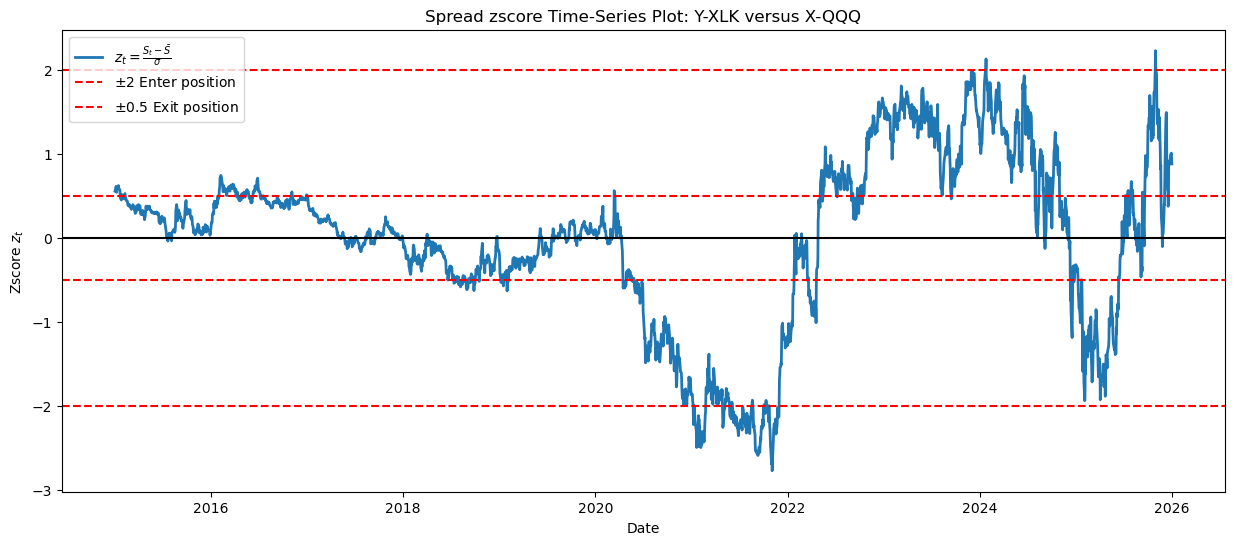

In [18]:
# spread zscore plot
plt.figure(figsize=(15, 6))
plt.plot(prices.index, zscore, linewidth=2, label=r"$z_t = \frac{S_t - \bar{S}}{\sigma} $")
plt.axhline(0, color="black")
plt.axhline(entry_threshold, color="red", linestyle="--", label=r"$\pm 2$ Enter position")
plt.axhline(-entry_threshold, color="red", linestyle="--")
plt.axhline(exit_threshold, color="red", linestyle="--", label=r"$\pm 0.5$ Exit position")
plt.axhline(-exit_threshold, color="red", linestyle="--")
plt.title(rf"Spread zscore Time-Series Plot: {ticker_y}/{ticker_x}")
plt.xlabel("Date")
plt.ylabel(r"Zscore $z_t$")
plt.legend()
plt.show()

In [21]:
positions = generate_spread_positions(
    zscore=zscore,
    entry_threshold=2.0,
    exit_threshold=0.5,
)

print(positions.head())
print(positions.value_counts())

Date
2015-01-02    0
2015-01-05    0
2015-01-06    0
2015-01-07    0
2015-01-08    0
Name: XLK_QQQ_spread_zscore_position, dtype: int64
XLK_QQQ_spread_zscore_position
 0    2356
 1     265
-1     145
Name: count, dtype: int64


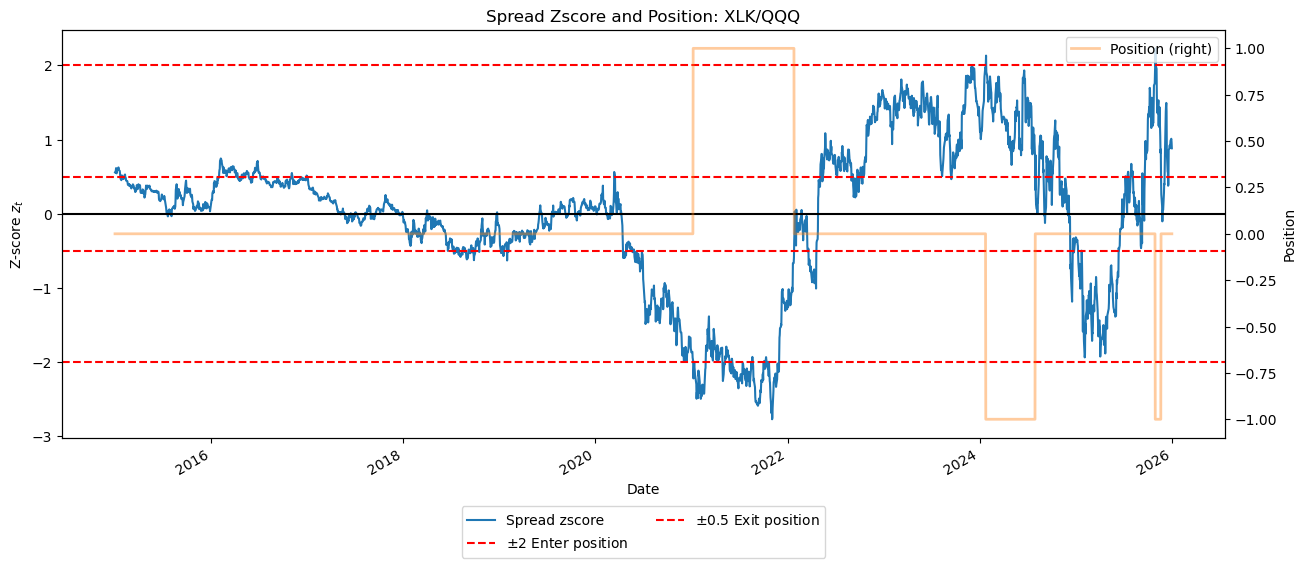

In [22]:
# plot positions along with the spread zscore
ax = zscore.plot(figsize=(15, 6), label="Spread zscore")

ax.axhline(0, color="black")
ax.axhline(entry_threshold, color="red", linestyle="--", label=r"$\pm 2$ Enter position")
ax.axhline(-entry_threshold, color="red", linestyle="--")
ax.axhline(exit_threshold, color="red", linestyle="--", label=r"$\pm 0.5$ Exit position")
ax.axhline(-exit_threshold, color="red", linestyle="--")

ax2 = positions.plot(secondary_y=True, linewidth=2, alpha=0.4, label="Position")

ax.set_title(f"Spread Zscore and Position: {ticker_y}/{ticker_x}")
ax.set_xlabel("Date")
ax.set_ylabel(r"Z-score $z_t$")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2)
ax2.set_ylabel("Position")
ax2.legend()

plt.show()

## Profitability

Let's compute our strategy returns $r_t$:

$$ r_t = \frac{\text{position}_{t-1} \times \text{spread PnL}_t}{\text{gross exposure}_{t-1}} - \text{transaction costs}_t $$

where the position is long/short/flat at $t-1$, the spread PnL$_t = \Delta Y_t - \beta \Delta X_t$ is how much money the spread made/lost at time $t$, $\text{gross exposure}_{t-1}$ scales the PnL into a percentage return at time $t-1$, and we subtract $\text{transaction costs}_t$ to account for trading costs when the position changes at time $t$. 

In [34]:
# compute strategy returns
strategy_returns = compute_strategy_returns(
    prices=prices,
    positions=positions,
    ticker_y=ticker_y,
    ticker_x=ticker_x,
    beta=beta,
)

print(strategy_returns.head())
print(strategy_returns.describe())
print(strategy_returns.isna().sum())

Date
2015-01-05    0.0
2015-01-06    0.0
2015-01-07   -0.0
2015-01-08   -0.0
2015-01-09    0.0
Name: XLK_QQQ_strategy_returns, dtype: float64
count    2765.000000
mean        0.000020
std         0.000678
min        -0.005636
25%         0.000000
50%         0.000000
75%         0.000000
max         0.006537
Name: XLK_QQQ_strategy_returns, dtype: float64
0


We can now compute our cumulative returns for the strategy, which answers the question: "If I started with $1 and reinvested each day's return, how much would I have over time?"

$$ \text{cumulative value}_t = \Pi_{i=1}^{t} (1+r_i)$$

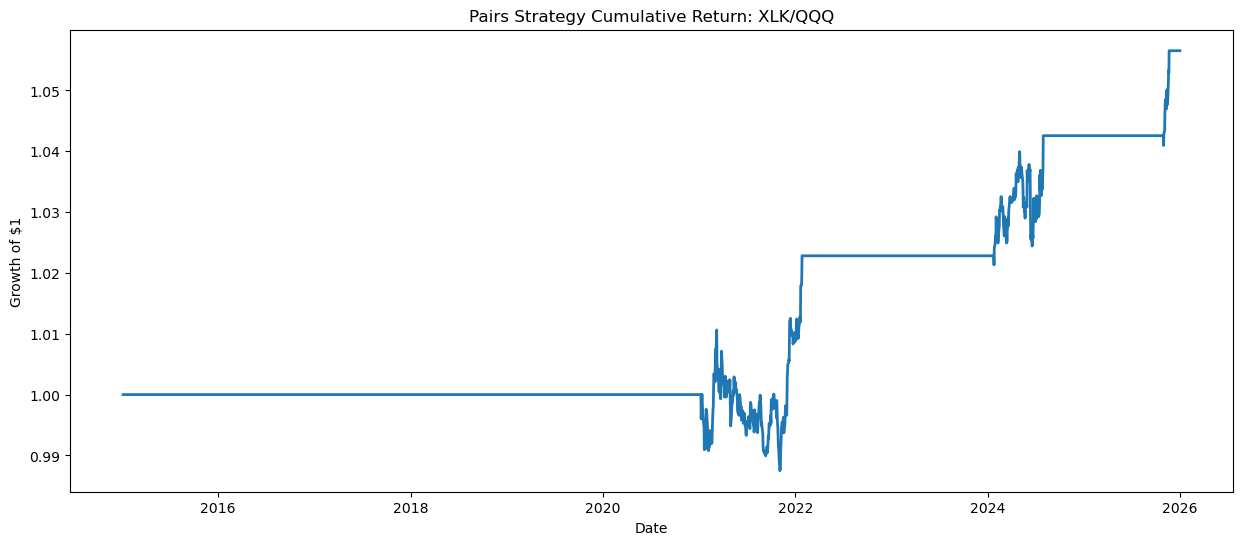

In [38]:
# plot cumulative strategy returns
cumulative_strategy_returns = compute_cumulative_returns(strategy_returns)

plt.figure(figsize=(15,6))
plt.plot(cumulative_strategy_returns, linewidth=2)
plt.title(f"Pairs Strategy Cumulative Return: {ticker_y}/{ticker_x}")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.show()

In [40]:
# inspect
print(strategy_returns.describe())
print(cumulative_strategy_returns.tail())

count    2765.000000
mean        0.000020
std         0.000678
min        -0.005636
25%         0.000000
50%         0.000000
75%         0.000000
max         0.006537
Name: XLK_QQQ_strategy_returns, dtype: float64
Date
2025-12-24    1.056531
2025-12-26    1.056531
2025-12-29    1.056531
2025-12-30    1.056531
2025-12-31    1.056531
Name: XLK_QQQ_strategy_returns_cumulative_returns, dtype: float64


In [41]:
metrics = compute_performance_metrics(strategy_returns)
print(cumulative_strategy_returns.tail())
for key, value in metrics.items():
    print(f"{key}: {value:.4f}")

Date
2025-12-24    1.056531
2025-12-26    1.056531
2025-12-29    1.056531
2025-12-30    1.056531
2025-12-31    1.056531
Name: XLK_QQQ_strategy_returns_cumulative_returns, dtype: float64
total_return: 0.0565
annualized_return: 0.0050
annualized_volatility: 0.0108
sharpe_ratio: 0.4713
max_drawdown: -0.0229


In [42]:
position_changes = positions.diff().fillna(0)

print(position_changes.value_counts())

XLK_QQQ_spread_zscore_position
 0.0    2760
 1.0       3
-1.0       3
Name: count, dtype: int64


In [45]:
n_position_changes = (positions.diff().fillna(0) != 0).sum()

days_in_market = (positions != 0).sum()
total_days = len(positions)

print("Number of position changes:", n_position_changes)
print("Days in market:", days_in_market)
print("Total days:", total_days)
print("Fraction in market:", days_in_market / total_days)

Number of position changes: 6
Days in market: 410
Total days: 2766
Fraction in market: 0.14822848879248013


In [49]:
strategy_returns_0bps = compute_strategy_returns(
    prices=prices,
    positions=positions,
    ticker_y=ticker_y,
    ticker_x=ticker_x,
    beta=beta,
    transaction_cost_bps=0.0,
)

strategy_returns_5bps = compute_strategy_returns(
    prices=prices,
    positions=positions,
    ticker_y=ticker_y,
    ticker_x=ticker_x,
    beta=beta,
    transaction_cost_bps=5.0,
)

strategy_returns_10bps = compute_strategy_returns(
    prices=prices,
    positions=positions,
    ticker_y=ticker_y,
    ticker_x=ticker_x,
    beta=beta,
    transaction_cost_bps=10.0,
)

In [52]:
for label, rets in {
    "0 bps": strategy_returns_0bps,
    "5 bps": strategy_returns_5bps,
    "10 bps": strategy_returns_10bps,
}.items():
    metrics = compute_performance_metrics(rets)

    print(label)
    for key, value in metrics.items():
        print(f"  {key}: {value:.4f}")
    print()

0 bps
  total_return: 0.0565
  annualized_return: 0.0050
  annualized_volatility: 0.0108
  sharpe_ratio: 0.4713
  max_drawdown: -0.0229

5 bps
  total_return: 0.0534
  annualized_return: 0.0047
  annualized_volatility: 0.0108
  sharpe_ratio: 0.4444
  max_drawdown: -0.0229

10 bps
  total_return: 0.0502
  annualized_return: 0.0045
  annualized_volatility: 0.0108
  sharpe_ratio: 0.4172
  max_drawdown: -0.0229



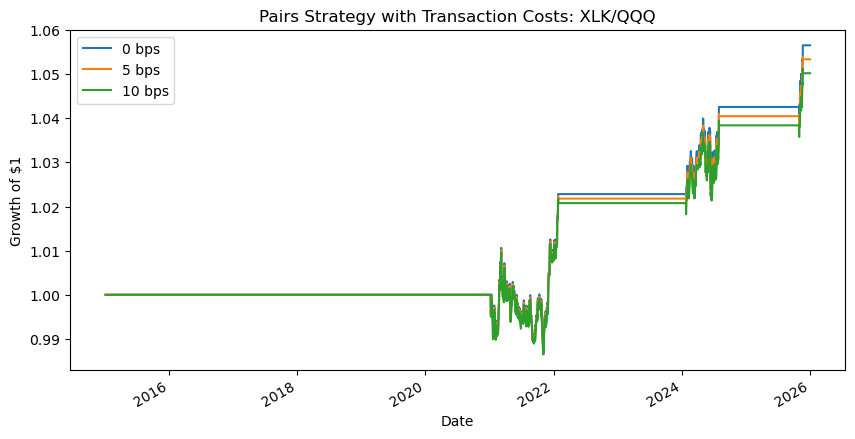

In [54]:
cum_0bps = compute_cumulative_returns(strategy_returns_0bps)
cum_5bps = compute_cumulative_returns(strategy_returns_5bps)
cum_10bps = compute_cumulative_returns(strategy_returns_10bps)

comparison = pd.concat(
    {
        "0 bps": cum_0bps,
        "5 bps": cum_5bps,
        "10 bps": cum_10bps,
    },
    axis=1,
)

ax = comparison.plot(figsize=(10, 5))

ax.set_title(f"Pairs Strategy with Transaction Costs: {ticker_y}/{ticker_x}")
ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1")
plt.show()

In [62]:
# inspect trades made
trade_log = build_trade_log(
    positions=positions,
    strategy_returns=strategy_returns_5bps,
)

print(trade_log)

  entry_date  exit_date     direction  holding_days  trade_return
0 2021-01-07 2022-01-26   long_spread           266      0.022306
1 2024-01-24 2024-07-30  short_spread           130      0.018795
2 2025-10-29 2025-11-20  short_spread            17      0.012889


In [65]:
print(trade_log["trade_return"].describe())
print("Number of trades:", len(trade_log))
print("Average holding days:", trade_log["holding_days"].mean())
print("Win rate:", (trade_log["trade_return"] > 0).mean())

count    3.000000
mean     0.017996
std      0.004759
min      0.012889
25%      0.015842
50%      0.018795
75%      0.020550
max      0.022306
Name: trade_return, dtype: float64
Number of trades: 3
Average holding days: 137.66666666666666
Win rate: 1.0


## Rolling Zscore

Our positions were based on using statistical quantities that had future information contained in them, since we were calculating these quantities over the entire time span of the data. This creates "look-ahead bias", the analysis benefits from hindsight, our futures influence the past. We can make our models smarter by removing this look-ahead bias via rolling statistical quantities. To fix up our zscore, we introduce the rolling zscore which is calculated using rolling means and rolling standard deviation. Then

$$ z_t = \frac{S_t - \bar{S}_w}{\sigma_w} $$

where $w$ denotes the window. We do the same analysis with the rolling zscore, and then compare.

In [80]:
# compute rolling zscore
rolling_zscore = compute_rolling_zscore(spread, window=60, lag=True)

print(rolling_zscore.head())
print(rolling_zscore.describe())

Date
2015-03-31   -0.947862
2015-04-01   -0.500025
2015-04-02   -0.563569
2015-04-06   -0.605981
2015-04-07   -0.579255
Name: XLK_QQQ_spread_rolling_zscore, dtype: float64
count    2706.000000
mean       -0.127431
std         1.414748
min        -4.392822
25%        -1.156881
50%        -0.226143
75%         0.910360
max         5.030923
Name: XLK_QQQ_spread_rolling_zscore, dtype: float64


In [85]:
rolling_positions = generate_spread_positions(
    zscore = rolling_zscore,
    entry_threshold=2.0,
    exit_threshold=0.5,
)

print(rolling_positions.value_counts())

XLK_QQQ_spread_rolling_zscore_position
 0    1557
 1     615
-1     534
Name: count, dtype: int64


In [88]:
rolling_strategy_returns = compute_strategy_returns(
    prices=prices,
    positions=rolling_positions,
    ticker_y=ticker_y,
    ticker_x=ticker_x,
    beta=beta,
    transaction_cost_bps=5.0,
)

rolling_metrics = compute_performance_metrics(rolling_strategy_returns)

for key, value in rolling_metrics.items():
    print(f"{key}: {value:.4f}")

total_return: 0.0725
annualized_return: 0.0065
annualized_volatility: 0.0198
sharpe_ratio: 0.3388
max_drawdown: -0.0347


In [91]:
rolling_trade_log = build_trade_log(
    positions=rolling_positions,
    strategy_returns=rolling_strategy_returns,
)

print(rolling_trade_log)
print("Number of trades:", len(rolling_trade_log))
print("Win rate:", (rolling_trade_log["trade_return"]>0).mean())
print("Average holding days:", rolling_trade_log["holding_days"].mean())

   entry_date  exit_date     direction  holding_days  trade_return
0  2015-04-24 2015-04-30   long_spread             5      0.008823
1  2015-06-18 2015-08-20   long_spread            45     -0.001580
2  2015-08-24 2015-08-27  short_spread             4      0.011865
3  2015-09-28 2015-10-16  short_spread            15      0.010645
4  2016-01-08 2016-04-01  short_spread            58     -0.015856
..        ...        ...           ...           ...           ...
57 2024-09-03 2024-09-11   long_spread             7      0.008961
58 2024-12-10 2025-02-26   long_spread            52     -0.004567
59 2025-05-13 2025-05-22  short_spread             8      0.004705
60 2025-06-12 2025-08-11  short_spread            41     -0.006231
61 2025-09-22 2025-11-11  short_spread            37     -0.002588

[62 rows x 5 columns]
Number of trades: 62
Win rate: 0.7580645161290323
Average holding days: 19.532258064516128


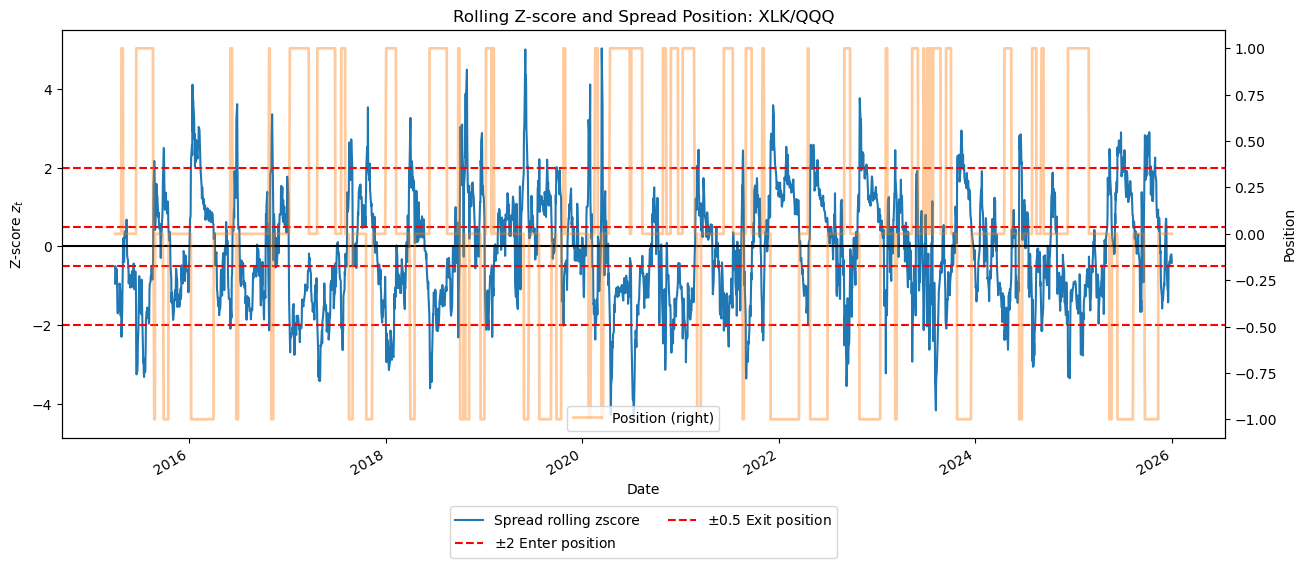

In [98]:
ax = rolling_zscore.plot(figsize=(15, 6), label="Spread rolling zscore")

ax.axhline(0, color="black")
ax.axhline(entry_threshold, color="red", linestyle="--", label=r"$\pm 2$ Enter position")
ax.axhline(-entry_threshold, color="red", linestyle="--")
ax.axhline(exit_threshold, color="red", linestyle="--", label=r"$\pm 0.5$ Exit position")
ax.axhline(-exit_threshold, color="red", linestyle="--")

ax2 = rolling_positions.plot(secondary_y=True, linewidth=2, alpha=0.4, label="Position")

ax.set_title(f"Rolling Z-score and Spread Position: {ticker_y}/{ticker_x}")
ax.set_xlabel("Date")
ax.set_ylabel("Z-score")
ax2.set_ylabel("Position")

ax.set_xlabel("Date")
ax.set_ylabel(r"Z-score $z_t$")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2)
ax2.set_ylabel("Position")
ax2.legend()

plt.show()

In [101]:
print("Counts")
print(rolling_positions.value_counts())

print("Number of position changes:", (rolling_positions.diff().fillna(0) != 0).sum())
print("Days in market:", (rolling_positions != 0).sum())
print("Total days:", len(rolling_positions))
print("Fraction in market:", (rolling_positions != 0).sum() / len(rolling_positions))

for key, value in rolling_metrics.items():
    print(f"{key}: {value:.4f}")

Counts
XLK_QQQ_spread_rolling_zscore_position
 0    1557
 1     615
-1     534
Name: count, dtype: int64
Number of position changes: 124
Days in market: 1149
Total days: 2706
Fraction in market: 0.4246119733924612
total_return: 0.0725
annualized_return: 0.0065
annualized_volatility: 0.0198
sharpe_ratio: 0.3388
max_drawdown: -0.0347


## Rolling Hedge Ratio

We now also introduce rolling spread, so $\alpha_t$ and $\beta_t$ are recalculated each timestep for specified windows of time.

$$Y_t = \alpha_t + \beta_t X_t + \epsilon_t$$ 

In [122]:
rolling_spread_df = compute_rolling_spread(
    prices=prices,
    ticker_y=ticker_y,
    ticker_x=ticker_x,
    window=252,
)

print(rolling_spread_df.head())
print(rolling_spread_df.tail())
print(rolling_spread_df.describe())

               alpha      beta    spread
date                                    
2016-01-04  3.224805  0.153891 -0.022995
2016-01-05  3.180938  0.154318 -0.044361
2016-01-06  3.137034  0.154747 -0.124913
2016-01-07  3.087401  0.155230 -0.183728
2016-01-08  3.034071  0.155750 -0.199248
                alpha      beta    spread
date                                     
2025-12-24 -31.000883  0.285479 -0.754000
2025-12-26 -30.986384  0.285439 -0.502977
2025-12-29 -30.978341  0.285414 -0.294135
2025-12-30 -30.963797  0.285385 -0.339401
2025-12-31 -30.950951  0.285357 -0.313973
             alpha         beta       spread
count  2514.000000  2514.000000  2514.000000
mean     -1.032526     0.215200     0.108681
std       7.955702     0.028811     1.321033
min     -31.424265     0.149119    -7.770455
25%      -4.754028     0.196481    -0.351182
50%      -1.117382     0.212595     0.142844
75%       2.240587     0.238097     0.635051
max      19.046538     0.286640     4.982690


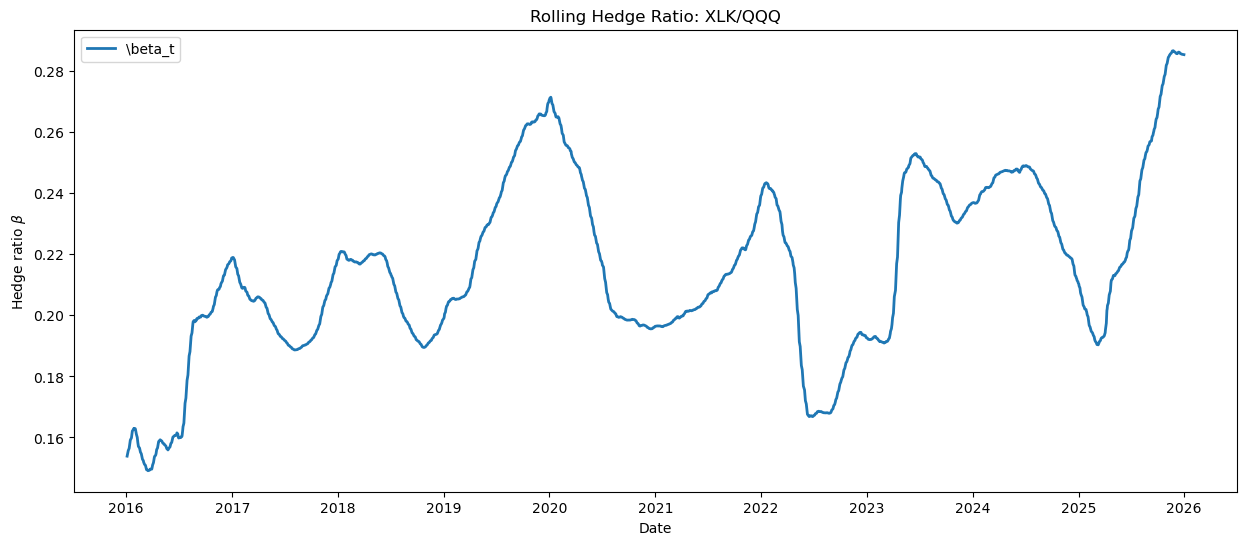

In [129]:
# plot rolling hedge ratio
plt.figure(figsize=(15, 6))
plt.plot(rolling_spread_df["beta"], linewidth=2, label=r"\beta_t")
plt.title(rf"Rolling Hedge Ratio: {ticker_y}/{ticker_x}")
plt.xlabel("Date")
plt.ylabel(r"Hedge ratio $\beta$")
plt.legend()
plt.show()

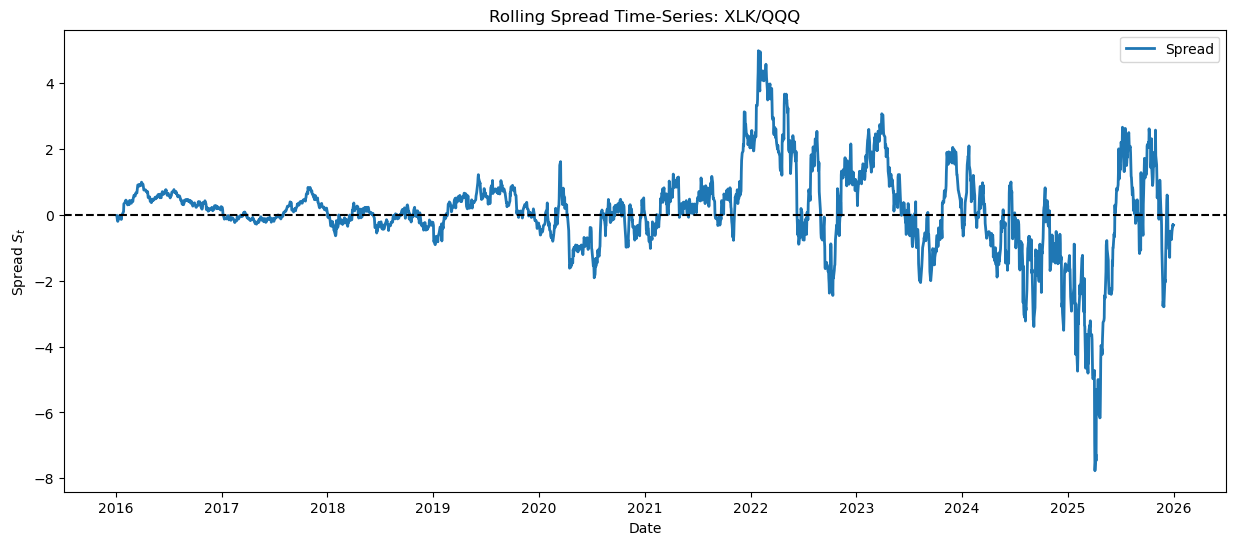

In [190]:
# spread zscore plot
plt.figure(figsize=(15, 6))
plt.plot(rolling_spread_df["spread"], linewidth=2, label=r"Spread")
plt.axhline(0, linestyle="--", color="black")
plt.title(rf"Rolling Spread Time-Series: {ticker_y}/{ticker_x}")
plt.xlabel("Date")
plt.ylabel(r"Spread $S_t$")
plt.legend()
plt.show()

In [143]:
rolling_spread = rolling_spread_df["spread"]

rolling_zscore = compute_rolling_zscore(
    spread=rolling_spread,
    window=60,
    lag=True,
)

rolling_positions = generate_spread_positions(
    zscore=rolling_zscore,
    entry_threshold=2.0,
    exit_threshold=0.5,
)

In [146]:
print(rolling_spread_df.shape)
print(rolling_spread_df.head())
print(rolling_spread_df[["alpha", "beta", "spread"]].describe())

(2514, 3)
               alpha      beta    spread
date                                    
2016-01-04  3.224805  0.153891 -0.022995
2016-01-05  3.180938  0.154318 -0.044361
2016-01-06  3.137034  0.154747 -0.124913
2016-01-07  3.087401  0.155230 -0.183728
2016-01-08  3.034071  0.155750 -0.199248
             alpha         beta       spread
count  2514.000000  2514.000000  2514.000000
mean     -1.032526     0.215200     0.108681
std       7.955702     0.028811     1.321033
min     -31.424265     0.149119    -7.770455
25%      -4.754028     0.196481    -0.351182
50%      -1.117382     0.212595     0.142844
75%       2.240587     0.238097     0.635051
max      19.046538     0.286640     4.982690


In [151]:
rolling_beta = rolling_spread_df["beta"]

In [166]:
rolling_zscore = compute_rolling_zscore(
    spread=rolling_spread,
    window=60,
    lag=True,
)

rolling_positions = generate_spread_positions(
    zscore=rolling_zscore,
    entry_threshold=2.0,
    exit_threshold=0.5,
)

dynamic_beta_returns = compute_strategy_returns_dynamic_beta(
    prices=prices,
    positions=rolling_positions,
    beta=rolling_beta,
    ticker_y=ticker_y,
    ticker_x=ticker_x,
    transaction_cost_bps=5.0,
)

dynamic_beta_metrics = compute_performance_metrics(dynamic_beta_returns)

for key, value in dynamic_beta_metrics.items():
    print(f"{key}: {value:.4f}")

total_return: 0.0738
annualized_return: 0.0073
annualized_volatility: 0.0192
sharpe_ratio: 0.3910
max_drawdown: -0.0301


In [169]:
print(len(rolling_spread))
print(len(rolling_zscore))
print(len(rolling_positions))
print(len(dynamic_beta_returns))
print(rolling_positions.value_counts())

2514
2454
2454
2454
spread_rolling_zscore_position
 0    1459
 1     541
-1     454
Name: count, dtype: int64


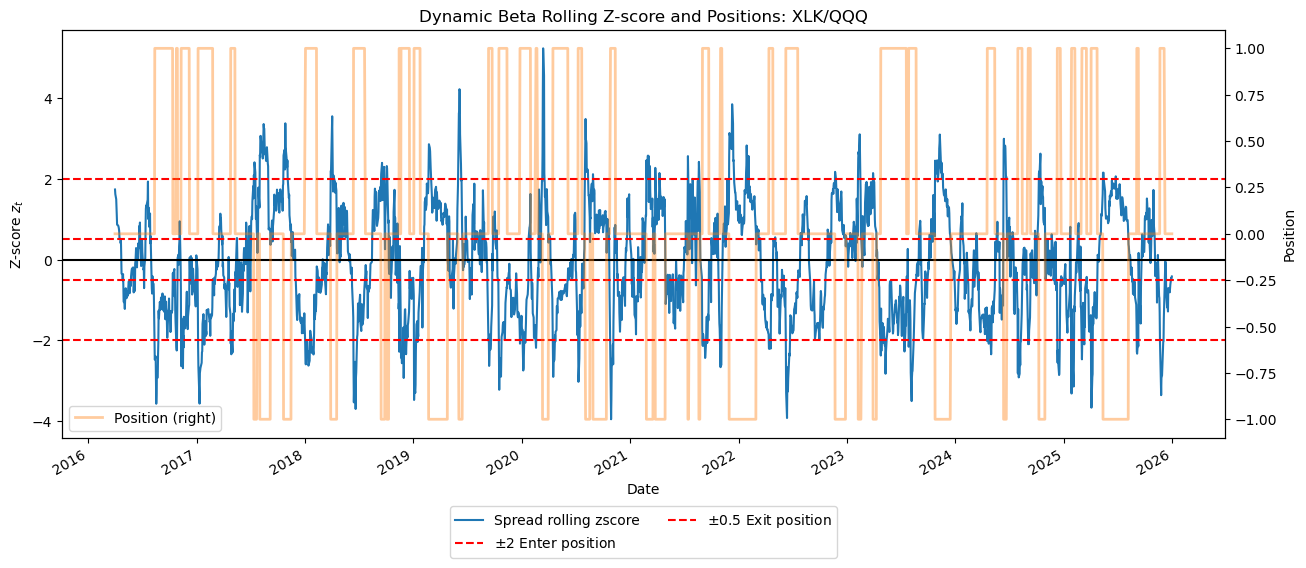

In [196]:
ax = rolling_zscore.plot(figsize=(15, 6), label="Spread rolling zscore")

ax.axhline(0, color="black")
ax.axhline(entry_threshold, color="red", linestyle="--", label=r"$\pm 2$ Enter position")
ax.axhline(-entry_threshold, color="red", linestyle="--")
ax.axhline(exit_threshold, color="red", linestyle="--", label=r"$\pm 0.5$ Exit position")
ax.axhline(-exit_threshold, color="red", linestyle="--")

ax2 = rolling_positions.plot(secondary_y=True, linewidth=2, alpha=0.4, label="Position")

ax.set_title(f"Dynamic Beta Rolling Z-score and Positions: {ticker_y}/{ticker_x}")
ax.set_xlabel("Date")
ax.set_ylabel("Z-score")
ax2.set_ylabel("Position")

ax.set_xlabel("Date")
ax.set_ylabel(r"Z-score $z_t$")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2)
ax2.set_ylabel("Position")
ax2.legend()

plt.show()

## Comparison
We compare the dynamic beta versus fixed beta strategy, where both have rolling zscore.

In [176]:
comparison_metrics = pd.DataFrame(
    {
        "fixed_beta_rolling_zscore": compute_performance_metrics(rolling_strategy_returns),
        "dynamic_beta_rolling_zscore": compute_performance_metrics(dynamic_beta_returns),
    }
).T

print(comparison_metrics.round(4))

                             total_return  annualized_return  \
fixed_beta_rolling_zscore          0.0725             0.0065   
dynamic_beta_rolling_zscore        0.0738             0.0073   

                             annualized_volatility  sharpe_ratio  max_drawdown  
fixed_beta_rolling_zscore                   0.0198        0.3388       -0.0347  
dynamic_beta_rolling_zscore                 0.0192        0.3910       -0.0301  


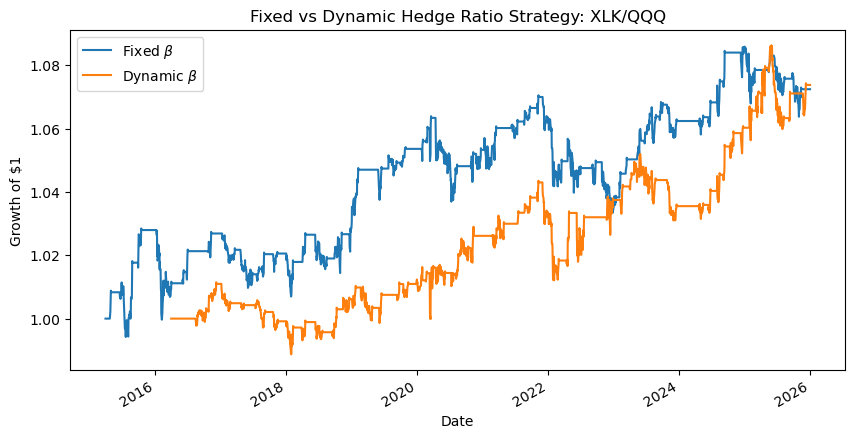

In [201]:
fixed_cum = compute_cumulative_returns(rolling_strategy_returns)
dynamic_cum = compute_cumulative_returns(dynamic_beta_returns)

comparison_cum = pd.concat(
    {
        r"Fixed $\beta$": fixed_cum,
        r"Dynamic $\beta$": dynamic_cum,
    },
    axis=1,
)

ax = comparison_cum.plot(figsize=(10, 5))

ax.set_title(f"Fixed vs Dynamic Hedge Ratio Strategy: {ticker_y}/{ticker_x}")
ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1")
plt.show()

In [182]:
dynamic_trade_log = build_trade_log(
    positions=rolling_positions,
    strategy_returns=dynamic_beta_returns,
)

print(dynamic_trade_log)
print("Number of trades:", len(dynamic_trade_log))
print("Win rate:", (dynamic_trade_log["trade_return"] > 0).mean())
print("Average holding days:", dynamic_trade_log["holding_days"].mean())
print(dynamic_trade_log["trade_return"].describe())

   entry_date  exit_date     direction  holding_days  trade_return
0  2016-08-12 2016-10-12   long_spread            43      0.003276
1  2016-10-24 2016-10-28   long_spread             5      0.004474
2  2016-11-09 2016-12-07   long_spread            20      0.004690
3  2017-01-05 2017-02-24   long_spread            35     -0.005548
4  2017-04-25 2017-05-10   long_spread            12     -0.000101
5  2017-07-12 2017-07-24  short_spread             9      0.001562
6  2017-08-01 2017-09-06  short_spread            26     -0.002716
7  2017-10-20 2017-11-15  short_spread            19     -0.002433
8  2018-01-02 2018-02-09   long_spread            28     -0.001477
9  2018-03-28 2018-04-18  short_spread            15      0.002231
10 2018-06-13 2018-07-23   long_spread            28     -0.002718
11 2018-09-14 2018-09-27  short_spread            10      0.002833
12 2018-10-03 2018-10-10  short_spread             6      0.005449
13 2018-11-14 2018-11-15   long_spread             2      0.00

In [185]:
print(comparison_metrics.round(4))
print("Number of trades:", len(dynamic_trade_log))
print("Win rate:", (dynamic_trade_log["trade_return"] > 0).mean())
print("Average holding days:", dynamic_trade_log["holding_days"].mean())

                             total_return  annualized_return  \
fixed_beta_rolling_zscore          0.0725             0.0065   
dynamic_beta_rolling_zscore        0.0738             0.0073   

                             annualized_volatility  sharpe_ratio  max_drawdown  
fixed_beta_rolling_zscore                   0.0198        0.3388       -0.0347  
dynamic_beta_rolling_zscore                 0.0192        0.3910       -0.0301  
Number of trades: 55
Win rate: 0.7454545454545455
Average holding days: 19.09090909090909
